**ITNPBD6-Machine Learning Assignment Autumn 2026**

**Telecom Customer Targeting**

**1. Data Understanding**

**Import Packages**

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

**Load the Wallace Communications Dataset**



In [2]:
df = pd.read_csv("wallacecommunications.csv")

In [3]:
df.shape

(50662, 20)

**Inspect Data and Check Missing Values**

Before training a model, I have to inspect the dataset to understand what I am dealing with. This helps avoid hidden problems like imbalance, missing values, or redundant features.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50662 entries, 0 to 50661
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         50662 non-null  int64  
 1   town                                       50662 non-null  object 
 2   country                                    50662 non-null  object 
 3   age                                        50662 non-null  int64  
 4   job                                        50662 non-null  object 
 5   married                                    50662 non-null  object 
 6   education                                  50662 non-null  object 
 7   arrears                                    50662 non-null  object 
 8   current_balance                            50662 non-null  float64
 9   housing                                    50662 non-null  object 
 10  has_tv_package        

In [5]:
df.head()

,ID,town,country,age,job,married,education,arrears,current_balance,housing,has_tv_package,last_contact,conn_tr,last_contact_this_campaign_day,last_contact_this_campaign_month,this_campaign,days_since_last_contact_previous_campaign,contacted_during_previous_campaign,outcome_previous_campaign,new_contract_this_campaign
0,32390233,Bristol,UK,39,management,married,tertiary,no,-1.90,no,yes,unknown,4,11,jun,8,-1,0,unknown,yes
1,41226029,Basildon,UK,53,housemaid,married,primary,no,3.62,no,no,cellular,1,28,jul,2,-1,0,unknown,yes
2,85498057,Blackburn,UK,79,retired,divorced,primary,no,27.87,no,no,telephone,3,13,jul,1,377,1,success,yes
3,76539627,Oldham,UK,43,services,single,secondary,no,5.50,yes,no,cellular,3,13,may,2,-1,0,unknown,no
4,76290986,Middlesbrough,UK,35,technician,single,secondary,no,3.44,no,no,cellular,2,27,aug,16,-1,0,unknown,yes


**Check for Duplicate Rows**

In [6]:
df.duplicated().sum()

np.int64(0)

**Check for Unique Values**

In [7]:
df.nunique()

,0
ID,50644
town,101
country,5
age,76
job,12
married,3
education,4
arrears,2
current_balance,6928
housing,2


**Idendify Column Data Types**

Correctly identifying data types is a very important step in data preprocessing, including data cleaning, exploratory data analysis, scaling, and encoding.

In [8]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print("Categorical columns: ", cat_col)
print("Numerical columns: ", num_col)

Categorical columns:  ['town', 'country', 'job', 'married', 'education', 'arrears', 'housing', 'has_tv_package', 'last_contact', 'last_contact_this_campaign_month', 'outcome_previous_campaign', 'new_contract_this_campaign']
Numerical columns:  ['ID', 'age', 'current_balance', 'conn_tr', 'last_contact_this_campaign_day', 'this_campaign', 'days_since_last_contact_previous_campaign', 'contacted_during_previous_campaign']


**2.Data cleaning & Preprocessing**

**Convert Target to Numeric**

This label encoding assigns numerical values (e.g., 0 and 1) to the categorical target variable. These transformations help my machine learning models process the data effectively.

In [9]:
df['new_contract_this_campaign'] = df['new_contract_this_campaign'].map({'yes': 1, 'no': 0})

In [10]:
df.head()

,ID,town,country,age,job,married,education,arrears,current_balance,housing,has_tv_package,last_contact,conn_tr,last_contact_this_campaign_day,last_contact_this_campaign_month,this_campaign,days_since_last_contact_previous_campaign,contacted_during_previous_campaign,outcome_previous_campaign,new_contract_this_campaign
0,32390233,Bristol,UK,39,management,married,tertiary,no,-1.90,no,yes,unknown,4,11,jun,8,-1,0,unknown,1
1,41226029,Basildon,UK,53,housemaid,married,primary,no,3.62,no,no,cellular,1,28,jul,2,-1,0,unknown,1
2,85498057,Blackburn,UK,79,retired,divorced,primary,no,27.87,no,no,telephone,3,13,jul,1,377,1,success,1
3,76539627,Oldham,UK,43,services,single,secondary,no,5.50,yes,no,cellular,3,13,may,2,-1,0,unknown,0
4,76290986,Middlesbrough,UK,35,technician,single,secondary,no,3.44,no,no,cellular,2,27,aug,16,-1,0,unknown,1


**Check Target Balance**

In [11]:
df['new_contract_this_campaign'].value_counts(normalize=True)

,proportion
new_contract_this_campaign,
0,0.804607
1,0.195393


**Visualize Target Variable Distribution**

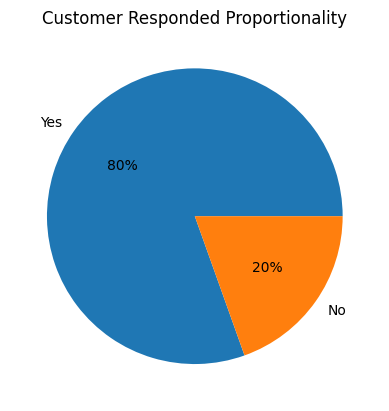

In [12]:
plt.pie(df['new_contract_this_campaign'].value_counts(), labels=['Yes', 'No'], autopct='%.f%%')
plt.title('Customer Responded Proportionality')
plt.show()

My dataset has an imbalance target, 0 - 80%, 1 - 20%. This is a moderate imbalance, significant enough to lead to misinterpretation. It seems accuracy alone will be misleading. Therefore, need additional evaluation metrics such as precision, recall, or graphs like the ROC-AUC curves

**Statistical Summary & Visualize Outliers**

In [13]:
df.drop(columns=['ID', 'new_contract_this_campaign']).describe().T

,count,mean,std,min,25%,50%,75%,max
age,50662.0,40.979373,10.919324,18.00,32.00,39.00,48.00,95.00
current_balance,50662.0,13.991210,30.899163,-80.19,0.82,4.72,14.95,984.17
conn_tr,50662.0,3.005093,1.409003,1.00,2.00,3.00,4.00,5.00
last_contact_this_campaign_day,50662.0,15.768525,8.347083,1.00,8.00,16.00,21.00,31.00
this_campaign,50662.0,2.713217,3.052227,1.00,1.00,2.00,3.00,63.00
days_since_last_contact_previous_campaign,50662.0,42.644408,102.238078,-1.00,-1.00,-1.00,-1.00,871.00
contacted_during_previous_campaign,50662.0,0.640283,2.358029,0.00,0.00,0.00,0.00,275.00


**Summarize the data distribution of numerical columns using boxplots**

This shows key features like range, median, and spread of the data, which makes it easier to understand the overall pattern of the data.

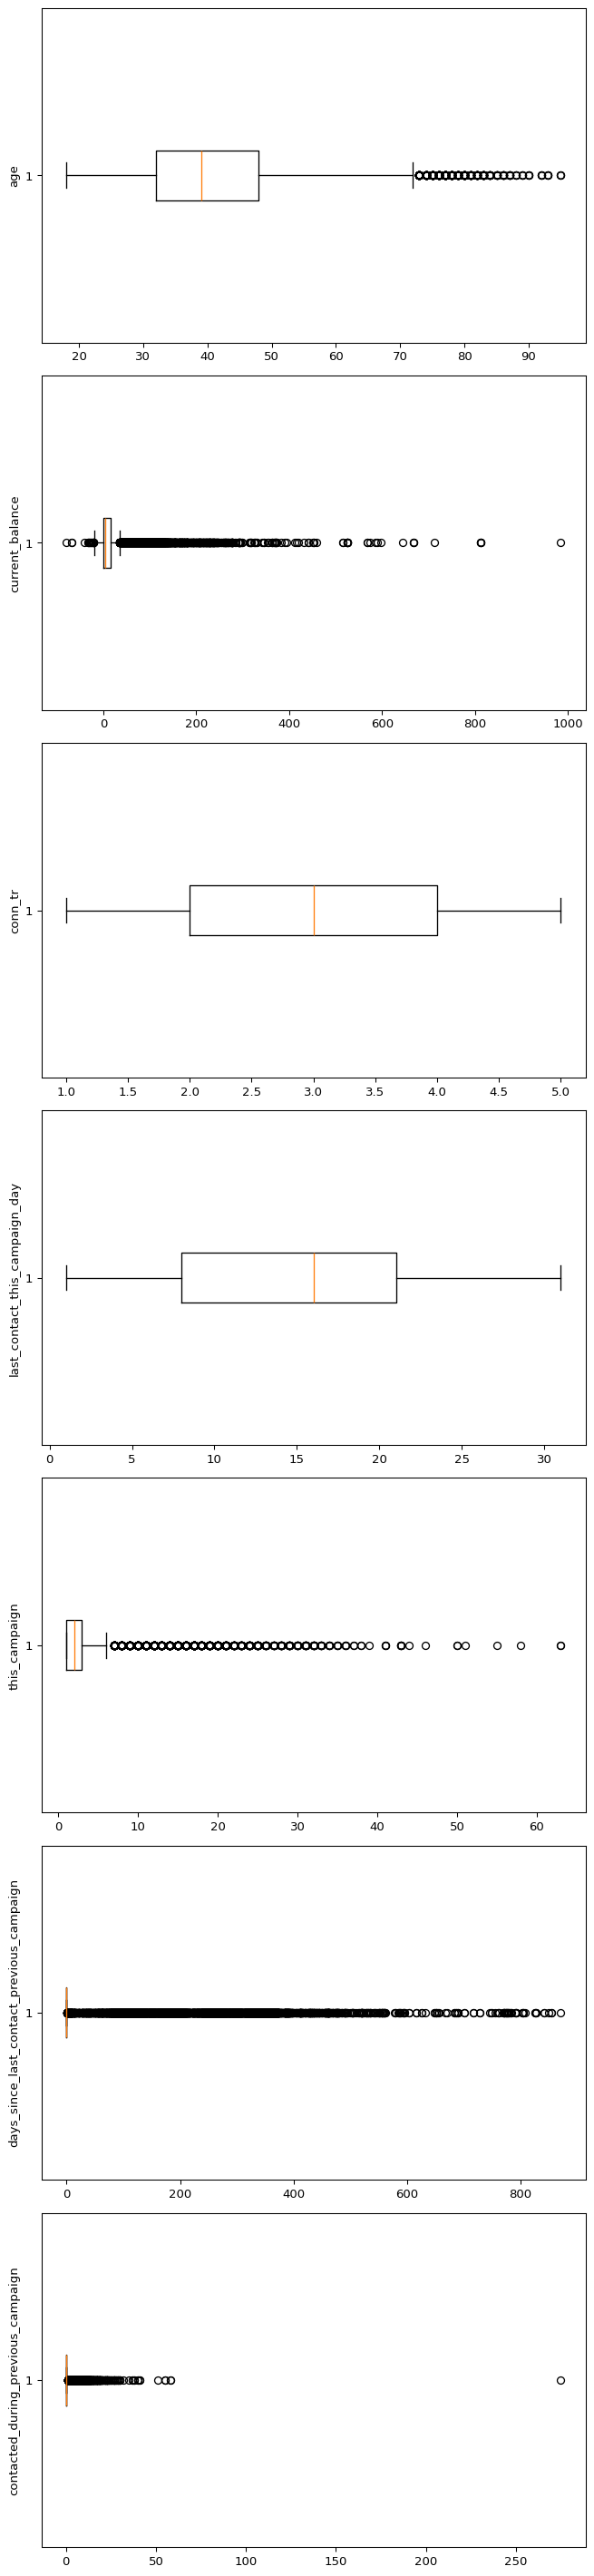

In [14]:
# Exclude ID
fix, axs = plt.subplots(len(num_col) - 1, 1, figsize=(7, 30), dpi=95)
for i, col in enumerate(num_col[1:]):
  axs[i].boxplot(df[col], vert=False)
  axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

As per the boxplots, outliers are found in many numericals, but these outliers matters differently in different models, such as Logistic regression and SVM are sensitive, while Random Forest and Neural Network are less sensitive.

Removing outliers using IQR(1st-99th percentile) may help without blindly removing.

**Correlation Analysis**

In [ ]:
pip install seaborn

Correlation analysis is a useful technique to identify relationships in data; these relationships help me understand the relevance of features with respect to the target class.

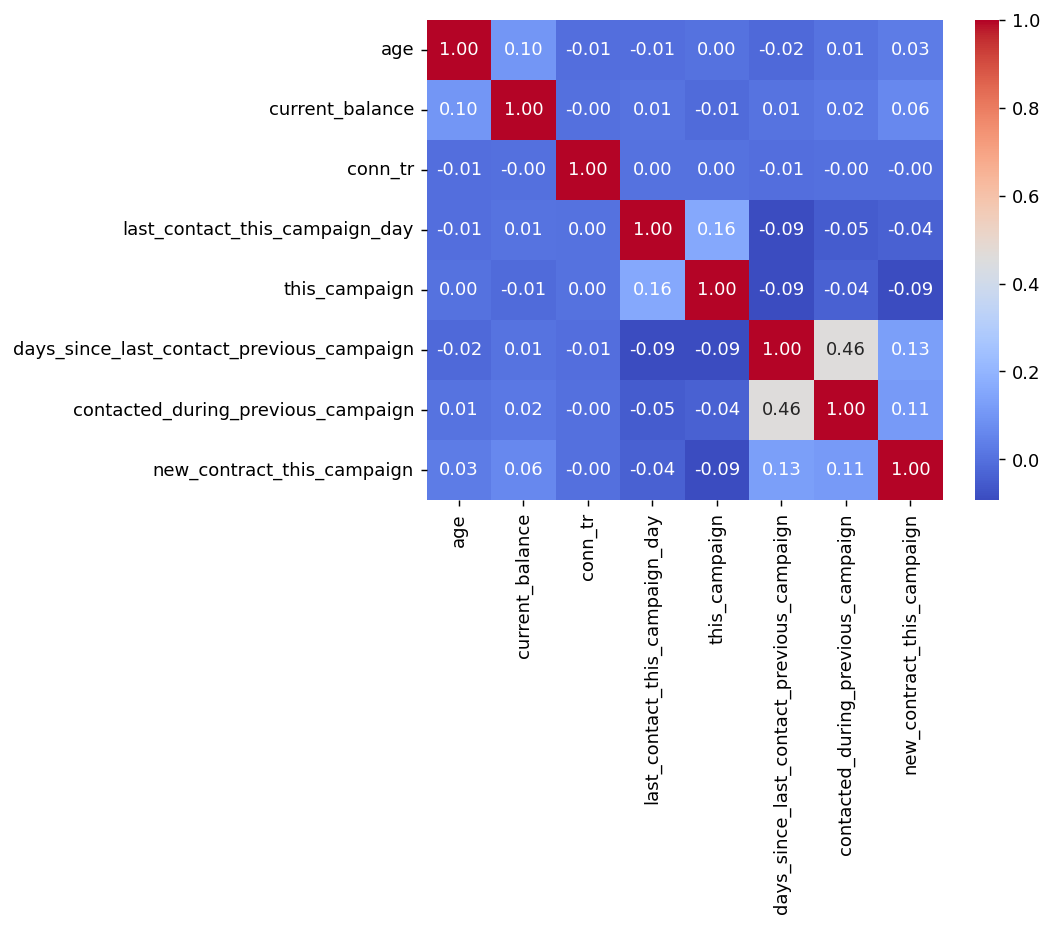

new_contract_this_campaign                   1.000000
days_since_last_contact_previous_campaign    0.126678
contacted_during_previous_campaign           0.112417
current_balance                              0.064008
age                                          0.030501
conn_tr                                     -0.002382
last_contact_this_campaign_day              -0.038615
this_campaign                               -0.091829
Name: new_contract_this_campaign, dtype: float64


In [15]:
df_corr = df.select_dtypes(include='number').drop(columns=['ID'])
corr = df_corr.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr["new_contract_this_campaign"].sort_values(ascending=False))

Overall, the correlation analysis shows that the non of the numerical columns have strong linear relationships with target variable. With weak correlation, removing outliers will not impact on model prediction.



**Kernel Density Plot to Understanding Variance in the Dataset**

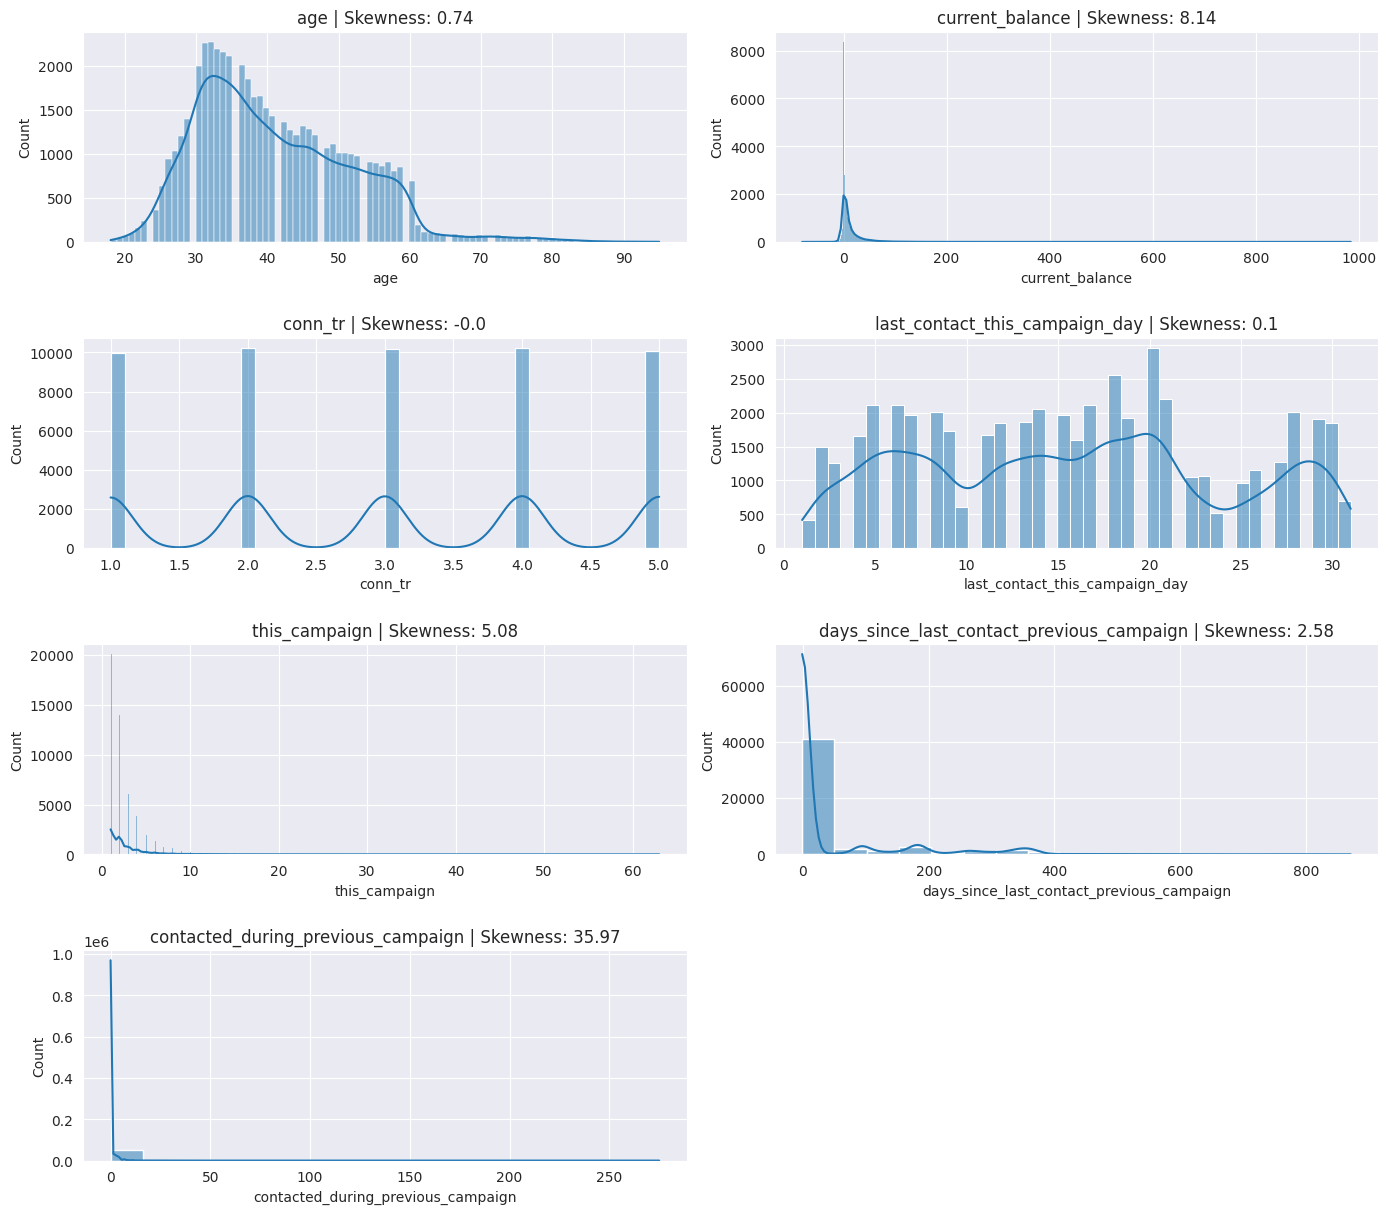

In [16]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include='number').columns[1:-1]

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

I noticed that the distribution is extremely skewed (> 5) for few features (current_balance, this_campaign, and contacted_during_previous_campaign). It can significantly impact model performance and interpretation. Also, it can lead to biased predictions, affect the accuracy of the models, and cause challenges in generalizing the model to new data.

Addressing and handling this skewness can improve the robustness and the fairness of my models.

**Handle Extremely Skewed Features**

Using the log transformation, the large values are scaled down more significantly than the smaller values. This transformation helps to make the distributions more symmetric than before.

Since the "current_balance" can contain negative values, adding a small constant (1) can fix this.

In [17]:
min_val = df['current_balance'].min()
df['current_balance'] = np.log1p(df['current_balance'] - min_val + 1)

df['this_campaign'] = np.log1p(df['this_campaign'])
df['contacted_during_previous_campaign'] = np.log1p(df['contacted_during_previous_campaign'])

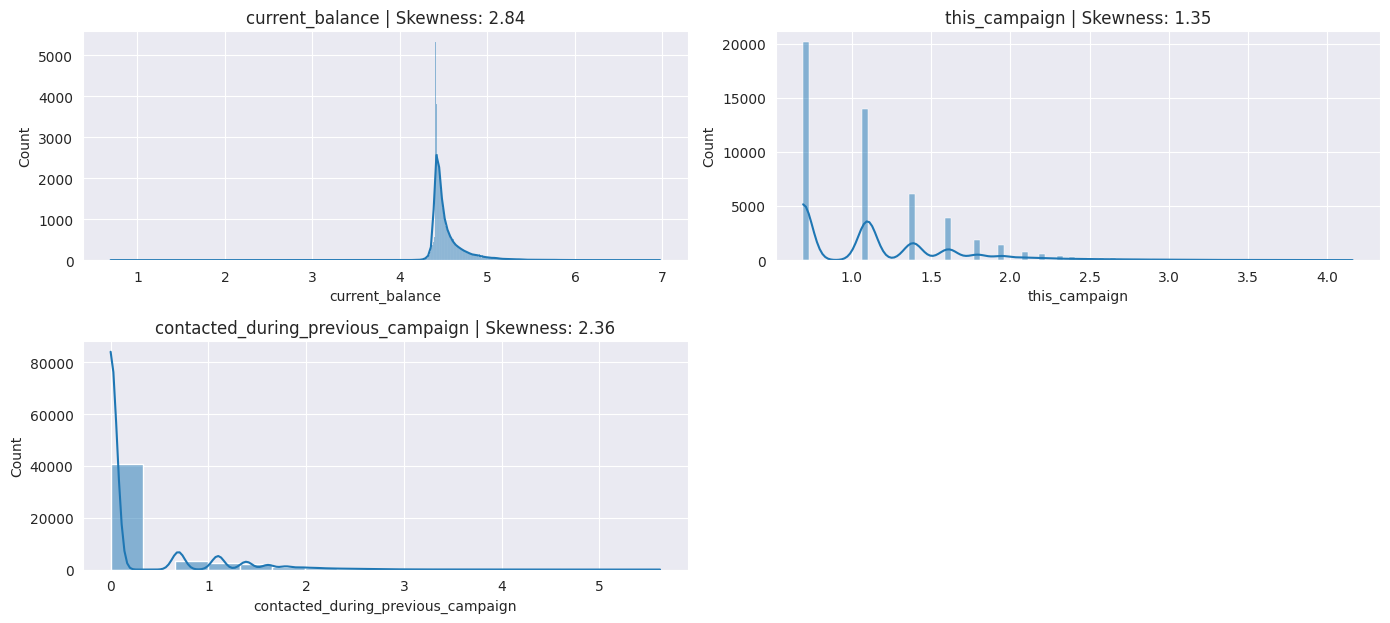

In [18]:
sns.set_style("darkgrid")

numerical_columns = ['current_balance', 'this_campaign', 'contacted_during_previous_campaign']

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

**Univariate Analysis**

This focuses on studying one variable at a time using a bar chart to understand its characteristics. This will help me understand the data and find patterns.

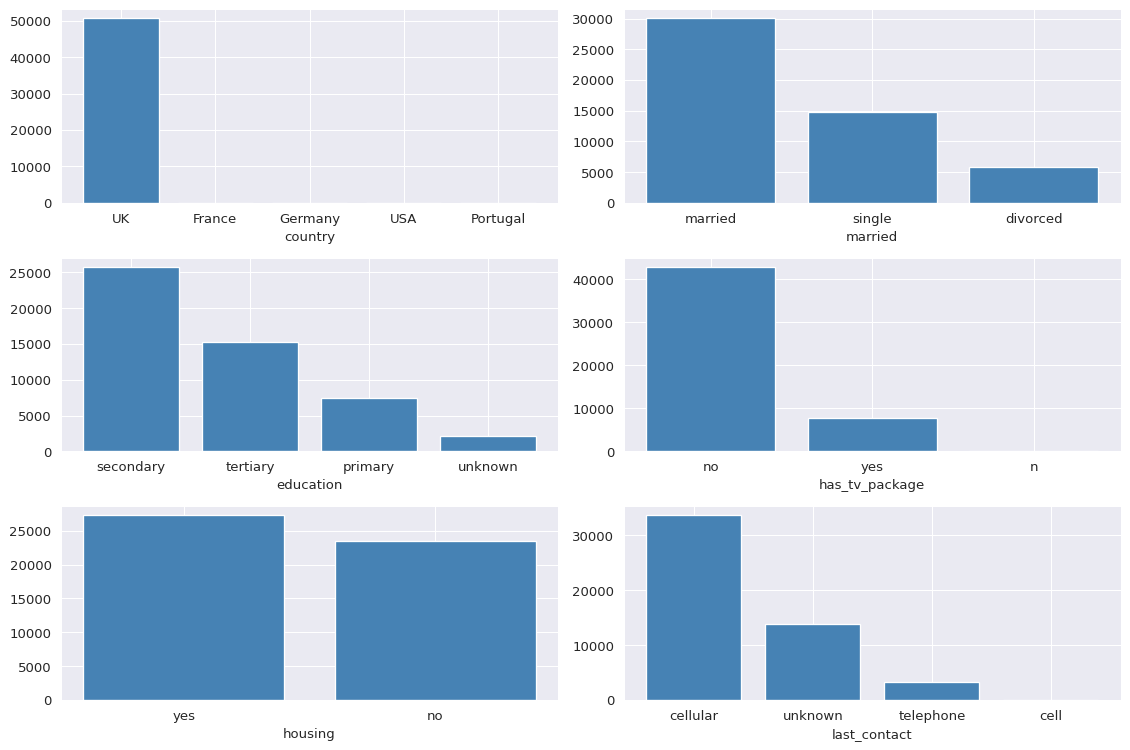

In [19]:
cat_col_filtered = ['country', 'married', 'education', 'has_tv_package', 'housing', 'last_contact']

fig, axs = plt.subplots(3, 2, figsize=(12, 8), dpi=95)
axs = axs.flatten()

for i, col in enumerate(cat_col_filtered):
  counts = df[col].value_counts()
  axs[i].bar(counts.index, counts, color='SteelBlue')
  axs[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [20]:
for col in cat_col_filtered:
  print(df[col].value_counts(), '\n')

country
UK          50657
France          2
Germany         1
USA             1
Portugal        1
Name: count, dtype: int64 

married
married     30045
single      14768
divorced     5849
Name: count, dtype: int64 

education
secondary    25779
tertiary     15314
primary       7474
unknown       2095
Name: count, dtype: int64 

has_tv_package
no     42886
yes     7771
n          5
Name: count, dtype: int64 

housing
yes    27250
no     23412
Name: count, dtype: int64 

last_contact
cellular     33595
unknown      13753
telephone     3312
cell             2
Name: count, dtype: int64 



**Handle Heavily Imbalanced Categorical Data**

The heavily imbalanced categorical feature(Country) can lead to biased models that perform poorly on minority class.

In [21]:
df['country'] = df['country'].apply(lambda x: x if x == 'UK' else 'others')
df['country'].value_counts()

,count
country,
UK,50657
others,5


**Handle Data Entry Error**

I think that the record "no" should have been placed in place of "n", which was mistakenly recorded. The data cleaning procedure must address this error.

In [22]:
df['has_tv_package'] = df['has_tv_package'].replace({'n': 'no'})
df['has_tv_package'].value_counts()

,count
has_tv_package,
no,42891
yes,7771


**Handle Data Glitch**

Similarly, I think that 'cellular' has been mistakenly recorded as 'cell'. The data cleaning procedure must address this error.

In [23]:
df['last_contact'] = df['last_contact'].replace({'cell': 'cellular'})
df['last_contact'].value_counts()

,count
last_contact,
cellular,33597
unknown,13753
telephone,3312


In [24]:
df = df.drop(columns=["ID"])
df.head()

,town,country,age,job,married,education,arrears,current_balance,housing,has_tv_package,last_contact,conn_tr,last_contact_this_campaign_day,last_contact_this_campaign_month,this_campaign,days_since_last_contact_previous_campaign,contacted_during_previous_campaign,outcome_previous_campaign,new_contract_this_campaign
0,Bristol,UK,39,management,married,tertiary,no,4.385645,no,yes,unknown,4,11,jun,2.197225,-1,0.000000,unknown,1
1,Basildon,UK,53,housemaid,married,primary,no,4.452136,no,no,cellular,1,28,jul,1.098612,-1,0.000000,unknown,1
2,Blackburn,UK,79,retired,divorced,primary,no,4.701026,no,no,telephone,3,13,jul,0.693147,377,0.693147,success,1
3,Oldham,UK,43,services,single,secondary,no,4.473808,yes,no,cellular,3,13,may,1.098612,-1,0.000000,unknown,0
4,Middlesbrough,UK,35,technician,single,secondary,no,4.450036,no,no,cellular,2,27,aug,2.833213,-1,0.000000,unknown,1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50662 entries, 0 to 50661
Data columns (total 19 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   town                                       50662 non-null  object 
 1   country                                    50662 non-null  object 
 2   age                                        50662 non-null  int64  
 3   job                                        50662 non-null  object 
 4   married                                    50662 non-null  object 
 5   education                                  50662 non-null  object 
 6   arrears                                    50662 non-null  object 
 7   current_balance                            50662 non-null  float64
 8   housing                                    50662 non-null  object 
 9   has_tv_package                             50662 non-null  object 
 10  last_contact          

**3. Feature Selection**

**Split the dataset into train and test sets**

In [26]:
X = df.drop("new_contract_this_campaign", axis='columns')
y = df["new_contract_this_campaign"]

print(f"X shape: {X.shape}, y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X shape: (50662, 18), y shape: (50662,)


To maintain the class imbalance (0: 80%, 1: 20%) in both sets, stratified splitting was used.

Cross check the Column Data Types

In [27]:
cat_col = [col for col in X.columns if X[col].dtype == 'object']
num_col = [col for col in X.columns if X[col].dtype != 'object']

print("Categorical columns: ", cat_col)
print("Numerical columns: ", num_col)

Categorical columns:  ['town', 'country', 'job', 'married', 'education', 'arrears', 'housing', 'has_tv_package', 'last_contact', 'last_contact_this_campaign_month', 'outcome_previous_campaign']
Numerical columns:  ['age', 'current_balance', 'conn_tr', 'last_contact_this_campaign_day', 'this_campaign', 'days_since_last_contact_previous_campaign', 'contacted_during_previous_campaign']


**4.Train Models**

The pipeline mechanism is used here to ensure processing in the right order.

The pipeline mechanism is used here to ensure processing in the right order. StandardScaler is used to standardize the values of numeric features, while onhot encoding is used to represent the categorical features as numerical features.

In [28]:
from sklearn.compose import ColumnTransformer

# numeric transformer
num_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# categorical transformer
cat_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))])

# combine them
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_col),
    ('cat', cat_transformer, cat_col)
])

In [29]:
#  Logistic Regression
# Pipeline
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ("clf", LogisticRegression(max_iter=500, random_state=42))
])

# Fit baseline
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'current_balance',
                                                   'conn_tr',
                                                   'last_contact_this_campaign_day',
                                                   'this_campaign',
                                                   'days_since_last_contact_previous_campaign',
                                                   'contacted_during_previous_campaign']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['town', 'country', 'job',
                                                   'married', 'education',
                                                   'arrears', 'housing',
                                                   'has_tv_package',
                                                   'last_contact',
                                                   'last_contact_this_campaign_month',
                                                   'outcome_previous_campaign'])])),
                ('clf', LogisticRegression(max_iter=500, random_state=42))])

In [ ]:
# # SVM
# # Pipeline
# pipe_svm = Pipeline([
#     ('preprocessor', preprocessor),
#     ("clf", SVC(probability=True, random_state=42))
# ])

# # Fit baseline
# pipe_svm.fit(X_train, y_train)

In [30]:
# Random Forest
preprocessor2 = ColumnTransformer(transformers=[
    ('num', "passthrough", num_col),
    ('cat', cat_transformer, cat_col)
])

# Pipeline
pipe_rf = Pipeline([
    ("preprocessor", preprocessor2),
    ("clf", RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Fit baseline
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'current_balance',
                                                   'conn_tr',
                                                   'last_contact_this_campaign_day',
                                                   'this_campaign',
                                                   'days_since_last_contact_previous_campaign',
                                                   'contacted_during_previous_campaign']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['town', 'country', 'job',
                                                   'married', 'education',
                                                   'arrears', 'housing',
                                                   'has_tv_package',
                                                   'last_contact',
                                                   'last_contact_this_campaign_month',
                                                   'outcome_previous_campaign'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [31]:
# Neural Network
# Pipeline
pipe_nn = Pipeline([
    ('preprocessor', preprocessor),
    ("clf", MLPClassifier(max_iter=500, random_state=42))
])

# Fit baseline
pipe_nn.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'current_balance',
                                                   'conn_tr',
                                                   'last_contact_this_campaign_day',
                                                   'this_campaign',
                                                   'days_since_last_contact_previous_campaign',
                                                   'contacted_during_previous_campaign']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['town', 'country', 'job',
                                                   'married', 'education',
                                                   'arrears', 'housing',
                                                   'has_tv_package',
                                                   'last_contact',
                                                   'last_contact_this_campaign_month',
                                                   'outcome_previous_campaign'])])),
                ('clf', MLPClassifier(max_iter=500, random_state=42))])

In [32]:
from lightgbm import LGBMClassifier

# LightGBM
preprocessor = ColumnTransformer(transformers=[
    ('num', "passthrough", num_col),
    ('cat', cat_transformer, cat_col)
])

# Pipeline
pipe_lg = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LGBMClassifier(objective='binary', random_state=42, class_weight='balanced'))
])

# Fit baseline
pipe_lg.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 7919, number of negative: 32610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 969
[LightGBM] [Info] Number of data points in the train set: 40529, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'current_balance',
                                                   'conn_tr',
                                                   'last_contact_this_campaign_day',
                                                   'this_campaign',
                                                   'days_since_last_contact_previous_campaign',
                                                   'contacted_during_previous_campaign']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['town', 'country', 'job',
                                                   'married', 'education',
                                                   'arrears', 'housing',
                                                   'has_tv_package',
                                                   'last_contact',
                                                   'last_contact_this_campaign_month',
                                                   'outcome_previous_campaign'])])),
                ('clf',
                 LGBMClassifier(class_weight='balanced', objective='binary',
                                random_state=42))])

In [33]:
y_pred_lr  = pipe_lr.predict(X_test)
# y_pred_svm = pipe_svm.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)
y_pred_nn = pipe_nn.predict(X_test)
y_pred_lg = pipe_lg.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [34]:
# Probabilities for curves
y_proba_lr  = pipe_lr.predict_proba(X_test)[:, 1]
# y_proba_svm = pipe_svm.predict_proba(X_test)[:, 1]
y_proba_rf = pipe_rf.predict_proba(X_test)[:,1]
y_proba_nn = pipe_nn.predict_proba(X_test)[:,1]
y_proba_lg = pipe_lg.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [35]:
def report(name, y_true, y_pred, y_proba):
    target_names = ['No', 'Yes']
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    roc = roc_auc_score(y_true, y_proba)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.3f} | Precision: {pr:.3f} | Recall: {rc:.3f} | F1: {f1:.3f} | ROC AUC: {roc:.3f}")
    print(classification_report(y_true, y_pred, target_names=target_names))
    return acc, pr, rc, f1, roc

In [36]:
metrics_lr  = report("Logistic Regression (baseline)", y_test, y_pred_lr, y_proba_lr)

=== Logistic Regression (baseline) ===
Accuracy: 0.838 | Precision: 0.716 | Recall: 0.284 | F1: 0.407 | ROC AUC: 0.773
              precision    recall  f1-score   support

          No       0.85      0.97      0.91      8153
         Yes       0.72      0.28      0.41      1980

    accuracy                           0.84     10133
   macro avg       0.78      0.63      0.66     10133
weighted avg       0.82      0.84      0.81     10133



In [ ]:
# metrics_svm = report("SVM (baseline)", y_test, y_pred_svm, y_proba_svm)

In [37]:
metrics_rf  = report("Random Forest (baseline)", y_test, y_pred_rf, y_proba_rf)

=== Random Forest (baseline) ===
Accuracy: 0.880 | Precision: 0.825 | Recall: 0.491 | F1: 0.616 | ROC AUC: 0.907
              precision    recall  f1-score   support

          No       0.89      0.97      0.93      8153
         Yes       0.82      0.49      0.62      1980

    accuracy                           0.88     10133
   macro avg       0.86      0.73      0.77     10133
weighted avg       0.88      0.88      0.87     10133



In [38]:
metrics_nn  = report("Neural Network (baseline)", y_test, y_pred_nn, y_proba_nn)

=== Neural Network (baseline) ===
Accuracy: 0.786 | Precision: 0.450 | Recall: 0.436 | F1: 0.443 | ROC AUC: 0.717
              precision    recall  f1-score   support

          No       0.86      0.87      0.87      8153
         Yes       0.45      0.44      0.44      1980

    accuracy                           0.79     10133
   macro avg       0.66      0.65      0.66     10133
weighted avg       0.78      0.79      0.78     10133



In [39]:
metrics_lg = report("LightGBM (baseline)", y_test, y_pred_lg, y_proba_lg)

=== LightGBM (baseline) ===
Accuracy: 0.813 | Precision: 0.518 | Recall: 0.663 | F1: 0.581 | ROC AUC: 0.834
              precision    recall  f1-score   support

          No       0.91      0.85      0.88      8153
         Yes       0.52      0.66      0.58      1980

    accuracy                           0.81     10133
   macro avg       0.71      0.76      0.73     10133
weighted avg       0.84      0.81      0.82     10133



**Confusion Matrices**

To evaluate the model's performance, I am using confusion matrices. This provides data practitioners with a deeper layer of insight into the model's performance, errors, and weaknesses.

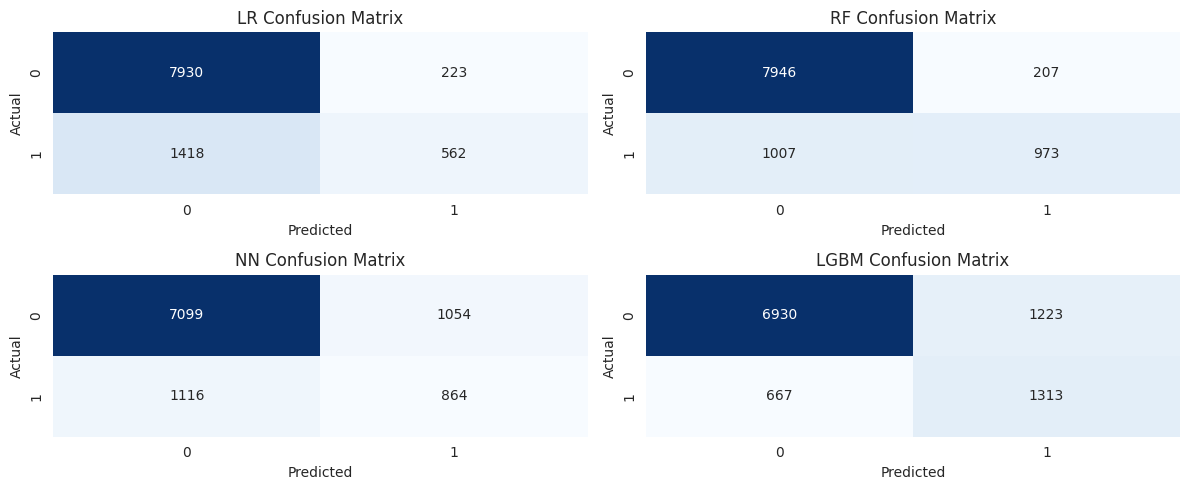

In [40]:
sns.set_style("darkgrid")

plt.figure(figsize=(12, 5))

# models = [("LR", y_pred_lr), ("SVM", y_pred_svm), ("RF", y_pred_rf), ("NN", y_pred_nn)]
models = [("LR", y_pred_lr), ("RF", y_pred_rf), ("NN", y_pred_nn), ("LGBM", y_pred_lg)]

for idx, (name, y_pred) in enumerate(models, start=1):
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(2, 2, idx)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

**ROC Curves**

To check how well my models work and to understand how well the models separate the positive cases,  I am using ROC curves.

<Figure size 600x500 with 0 Axes>

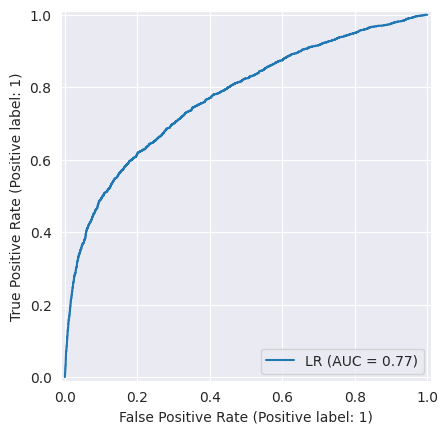

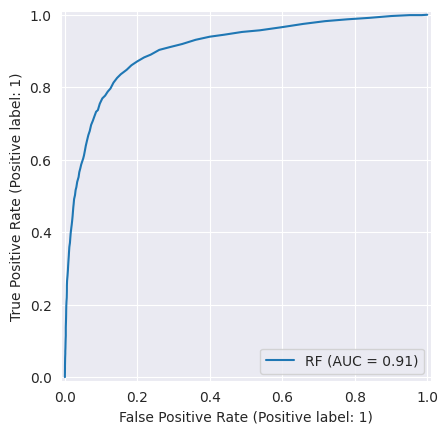

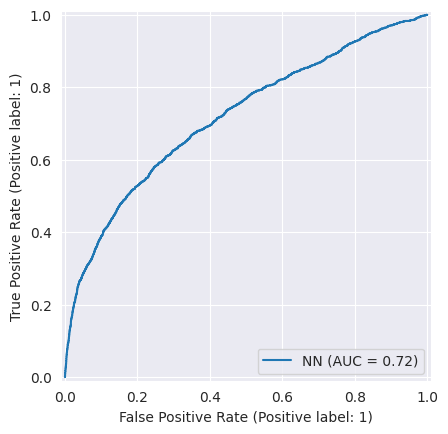

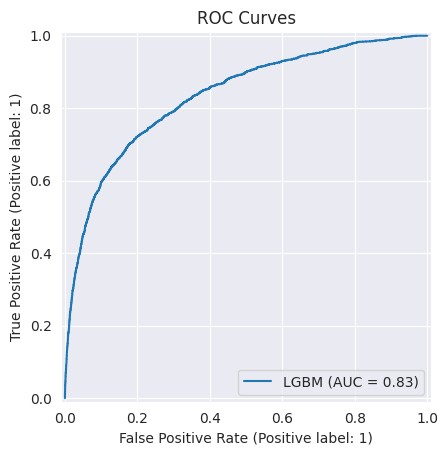

In [41]:
# ROC Curves
fig = plt.figure(figsize=(6, 5))

RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="LR")
# RocCurveDisplay.from_predictions(y_test, y_proba_svm, name="SVM")
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="RF")
RocCurveDisplay.from_predictions(y_test, y_proba_nn, name="NN")
RocCurveDisplay.from_predictions(y_test, y_proba_lg, name="LGBM")
plt.title("ROC Curves")
plt.show()

**Precision-Recall curves**

To measure how well minority classes are predicted, I use precision-recall curves.

<Figure size 600x500 with 0 Axes>

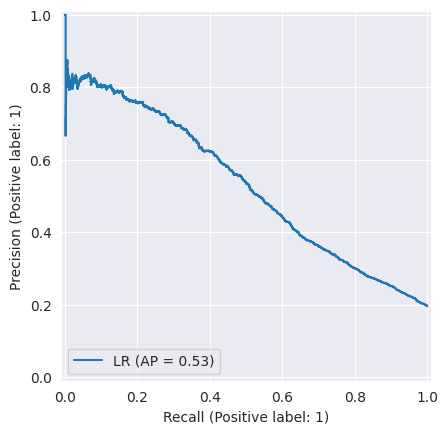

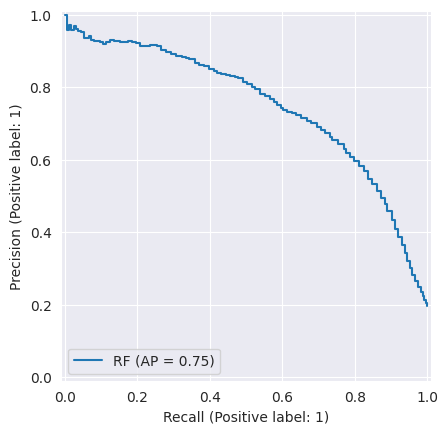

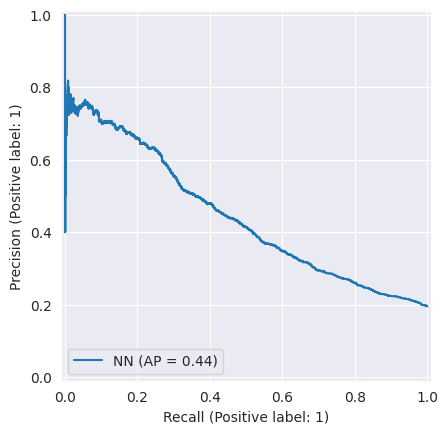

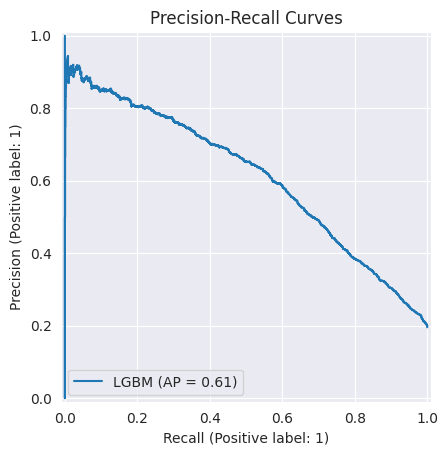

In [42]:
# Precision-Recall curves
fig = plt.figure(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, name="LR")
# PrecisionRecallDisplay.from_predictions(y_test, y_proba_svm, name="SVM")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, name="RF")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_nn, name="NN")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lg, name="LGBM")
plt.title("Precision-Recall Curves")
plt.show()

**5-fold Stratified CV scores (Accuracy)**

Since my target variable is imbalanced (0: 80%, 1: 20%), this method ensures that each folds maintains the same proportion of classes.

In [43]:
# 5-fold Stratified CV scores (Accuracy)
num_folds = 5
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

cv_lr  = cross_val_score(pipe_lr,  X, y, cv=kf, scoring="accuracy")
# cv_svm = cross_val_score(pipe_svm, X, y, cv=kf, scoring="accuracy")
cv_rf = cross_val_score(pipe_rf, X, y, cv=kf, scoring="accuracy")
cv_nn = cross_val_score(pipe_nn, X, y, cv=kf, scoring="accuracy")
cv_lg = cross_val_score(pipe_lg, X, y, cv=kf, scoring="accuracy")

print(f"LR CV Accuracy:  mean={cv_lr.mean():.3f} ± {cv_lr.std():.3f}")
# print(f"SVM CV Accuracy: mean={cv_svm.mean():.3f} ± {cv_svm.std():.3f}")
print(f"RF CV Accuracy: mean={cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"NN CV Accuracy: mean={cv_nn.mean():.3f} ± {cv_nn.std():.3f}")
print(f"LGBM Accuracy: mean={cv_lg.mean():.3f} ± {cv_lg.std():.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: Conv

[LightGBM] [Info] Number of positive: 7919, number of negative: 32610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005892 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 968
[LightGBM] [Info] Number of data points in the train set: 40529, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 7919, number of negative: 32610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 969
[LightGBM] [Info] Number of data points in the train set: 40529, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 7919, number of negative: 32611
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 969
[LightGBM] [Info] Number of data points in the train set: 40530, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 7920, number of negative: 32610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 971
[LightGBM] [Info] Number of data points in the train set: 40530, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LR CV Accuracy:  mean=0.836 ± 0.002
RF CV Accuracy: mean=0.876 ± 0.002
NN CV Accuracy: mean=0.781 ± 0.007
LGBM Accuracy: mean=0.808 ± 0.006


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


**Hyperparameter Tuning**

To tweak model performance for optimal performance, I use Hyperparameter tuning, which allows me to choose appropriate hyperparameter values that maximize the model's predictive accuracy.

In [44]:
# Logistic Regression
grid_lr = {
    "clf__solver": ["lbfgs", "liblinear"],
    "clf__penalty": ["l2"],
    "clf__C": [0.01, 0.1, 1.0, 3.0, 10.0],
    "clf__max_iter": [5000],
}

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=grid_lr,
    cv=kf,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)
gs_lr.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'current_balance',
                                                                          'conn_tr',
                                                                          'last_contact_this_campaign_day',
                                                                          'this_campaign',
                                                                          'days_since_last_contact_previous_campaign',
                                                                          'contacted_during_prev...
                                                                          'married',
                                                                          'education',
                                                                          'arrears',
                                                                          'housing',
                                                                          'has_tv_package',
                                                                          'last_contact',
                                                                          'last_contact_this_campaign_month',
                                                                          'outcome_previous_campaign'])])),
                                       ('clf',
                                        LogisticRegression(max_iter=500,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.01, 0.1, 1.0, 3.0, 10.0],
                         'clf__max_iter': [5000], 'clf__penalty': ['l2'],
                         'clf__solver': ['lbfgs', 'liblinear']},
             scoring='roc_auc')

In [ ]:
print("Best LR params:", gs_lr.best_params_, "AUC:", gs_lr.best_score_)

Best LR params: {'clf__C': 0.1, 'clf__max_iter': 5000, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'} AUC: 0.7646521147572669


In [ ]:
# # SVM
# grid_svm = {
#     "clf__C": [0.1, 1, 10, 100],
#     "clf__kernel": ['linear', 'rbf'],
#     "clf__gamma": ['scale', 'auto'],
#     "clf__class_weight": [None, 'balanced']
# }

# rand_svm = RandomizedSearchCV(
#     estimator=pipe_svm,
#     param_distributions=grid_svm,
#     n_iter=30,
#     cv=kf3,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1
#   )
# rand_svm.fit(X_train, y_train)

In [ ]:
# print("Best SVM params:", rand_svm.best_params_, "AUC:", rand_svm.best_score_)

In [45]:
# Random Forest
grid_rf = {
    "clf__n_estimators": [50, 100, 200, 300],
    "clf__max_depth": [None, 10, 20, 30, 40],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
    "clf__bootstrap": [True, False],
    "clf__class_weight": [None, "balanced"]
}


rand_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=grid_rf,
    n_iter=30,
    cv=kf,
    scoring="roc_auc",
    verbose=2,
    random_state=42,
    n_jobs=-1
)
rand_rf.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               ['age',
                                                                                'current_balance',
                                                                                'conn_tr',
                                                                                'last_contact_this_campaign_day',
                                                                                'this_campaign',
                                                                                'days_since_last_contact_previous_campaign',
                                                                                'contacted_during_previous_campaign']),
                                                                              ('cat',
                                                                               Pi...
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'clf__bootstrap': [True, False],
                                        'clf__class_weight': [None, 'balanced'],
                                        'clf__max_depth': [None, 10, 20, 30,
                                                           40],
                                        'clf__max_features': ['sqrt', 'log2'],
                                        'clf__min_samples_leaf': [1, 2, 4],
                                        'clf__min_samples_split': [2, 5, 10],
                                        'clf__n_estimators': [50, 100, 200,
                                                              300]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [46]:
print("Best RF params:", rand_rf.best_params_, "AUC:", rand_rf.best_score_)

Best RF params: {'clf__n_estimators': 50, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': None, 'clf__class_weight': None, 'clf__bootstrap': False} AUC: 0.8748656528278431


In [47]:
# Neural Network
grid_nn = {
    'clf__hidden_layer_sizes': [(50,), (100,), (50,50), (100,50)],
    'clf__activation': ['relu', 'tanh'],
    'clf__solver': ['adam', 'sgd'],
    'clf__alpha': [0.0001, 0.001, 0.01],
    'clf__learning_rate_init': [0.001, 0.01],
    'clf__early_stopping': [True]
}

rand_nn = RandomizedSearchCV(
    estimator=pipe_nn,
    param_distributions=grid_nn,
    n_iter=30,
    cv=kf,
    scoring='roc_auc',
    verbose=2,
    random_state=42,
    n_jobs=-1
)
rand_nn.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'current_balance',
                                                                                'conn_tr',
                                                                                'last_contact_this_campaign_day',
                                                                                'this_campaign',
                                                                                'days_since_last_contact_previous_campaign',
                                                                                'contacted_durin...
                                              MLPClassifier(max_iter=500,
                                                            random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'clf__activation': ['relu', 'tanh'],
                                        'clf__alpha': [0.0001, 0.001, 0.01],
                                        'clf__early_stopping': [True],
                                        'clf__hidden_layer_sizes': [(50,),
                                                                    (100,),
                                                                    (50, 50),
                                                                    (100, 50)],
                                        'clf__learning_rate_init': [0.001,
                                                                    0.01],
                                        'clf__solver': ['adam', 'sgd']},
                   random_state=42, scoring='roc_auc', verbose=2)

In [48]:
print("Best NN params:", rand_nn.best_params_, "AUC:", rand_nn.best_score_)

Best NN params: {'clf__solver': 'adam', 'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (50, 50), 'clf__early_stopping': True, 'clf__alpha': 0.01, 'clf__activation': 'tanh'} AUC: 0.7891170208475389


In [49]:
grid_lg = {
    "clf__num_leaves": [50, 100, 150],
    "clf__max_depth": [-1, 10, 20, 30],
    "clf__learning_rate": [0.1, 0.05, 0.01],
    "clf__n_estimators": [100, 200, 500],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0]
}

rand_lg = RandomizedSearchCV(
    pipe_lg,
    param_distributions=grid_lg,
    n_iter=20,
    cv=kf,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rand_lg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 7919, number of negative: 32610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 969
[LightGBM] [Info] Number of data points in the train set: 40529, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               'passthrough',
                                                                               ['age',
                                                                                'current_balance',
                                                                                'conn_tr',
                                                                                'last_contact_this_campaign_day',
                                                                                'this_campaign',
                                                                                'days_since_last_contact_previous_campaign',
                                                                                'contacted_during_previous_campaign']),
                                                                              ('cat',
                                                                               Pi...
                                              LGBMClassifier(class_weight='balanced',
                                                             objective='binary',
                                                             random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'clf__colsample_bytree': [0.6, 0.8,
                                                                  1.0],
                                        'clf__learning_rate': [0.1, 0.05, 0.01],
                                        'clf__max_depth': [-1, 10, 20, 30],
                                        'clf__n_estimators': [100, 200, 500],
                                        'clf__num_leaves': [50, 100, 150],
                                        'clf__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [50]:
print("Best LGBM params:", rand_lg.best_params_, "AUC:", rand_lg.best_score_)

Best LGBM params: {'clf__subsample': 0.8, 'clf__num_leaves': 150, 'clf__n_estimators': 200, 'clf__max_depth': 20, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.6} AUC: 0.871508710790947


**Evaluate Best Models**

In [51]:
best_lr  = gs_lr.best_estimator_
# best_svm = gs_svm.best_estimator_
best_rf = rand_rf.best_estimator_
best_nn = rand_nn.best_estimator_
best_lg = rand_lg.best_estimator_

In [52]:
y_pred_lr_best  = best_lr.predict(X_test)
# y_pred_svm_best = best_svm.predict(X_test)
y_pred_rf_best = best_rf.predict(X_test)
y_pred_nn_best = best_nn.predict(X_test)
y_pred_lg_best = best_lg.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [53]:
# Probabilities (best) for curves
y_proba_lr_best  = best_lr.predict_proba(X_test)[:, 1]
# y_proba_svm_best = best_svm.predict_proba(X_test)[:, 1]
y_proba_rf_best = best_rf.predict_proba(X_test)[:,1]
y_proba_nn_best = best_nn.predict_proba(X_test)[:,1]
y_proba_lg_best = best_lg.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [54]:
metrics_lr_best  = report("Tuned Logistic Regression", y_test, y_pred_lr_best, y_proba_lr_best)

=== Tuned Logistic Regression ===
Accuracy: 0.837 | Precision: 0.719 | Recall: 0.274 | F1: 0.397 | ROC AUC: 0.774
              precision    recall  f1-score   support

          No       0.85      0.97      0.91      8153
         Yes       0.72      0.27      0.40      1980

    accuracy                           0.84     10133
   macro avg       0.78      0.62      0.65     10133
weighted avg       0.82      0.84      0.81     10133



In [ ]:
# metrics_svm_best = report("Tuned SVM", y_test, y_pred_svm_best, y_proba_svm_best)

In [55]:
metrics_rf_best  = report("Tuned Random Forest", y_test, y_pred_rf_best, y_proba_rf_best)

=== Tuned Random Forest ===
Accuracy: 0.886 | Precision: 0.837 | Recall: 0.515 | F1: 0.637 | ROC AUC: 0.905
              precision    recall  f1-score   support

          No       0.89      0.98      0.93      8153
         Yes       0.84      0.51      0.64      1980

    accuracy                           0.89     10133
   macro avg       0.86      0.75      0.78     10133
weighted avg       0.88      0.89      0.87     10133



In [56]:
metrics_nn  = report("Tuned Neural Network", y_test, y_pred_nn_best, y_proba_nn_best)

=== Tuned Neural Network ===
Accuracy: 0.847 | Precision: 0.678 | Recall: 0.414 | F1: 0.514 | ROC AUC: 0.796
              precision    recall  f1-score   support

          No       0.87      0.95      0.91      8153
         Yes       0.68      0.41      0.51      1980

    accuracy                           0.85     10133
   macro avg       0.77      0.68      0.71     10133
weighted avg       0.83      0.85      0.83     10133



In [57]:
metrics_lg = report("Tuned LightGBM", y_test, y_pred_lg_best, y_proba_lg_best)

=== Tuned LightGBM ===
Accuracy: 0.861 | Precision: 0.626 | Recall: 0.712 | F1: 0.666 | ROC AUC: 0.894
              precision    recall  f1-score   support

          No       0.93      0.90      0.91      8153
         Yes       0.63      0.71      0.67      1980

    accuracy                           0.86     10133
   macro avg       0.78      0.80      0.79     10133
weighted avg       0.87      0.86      0.86     10133



**Confusion Matrices for Best Models**

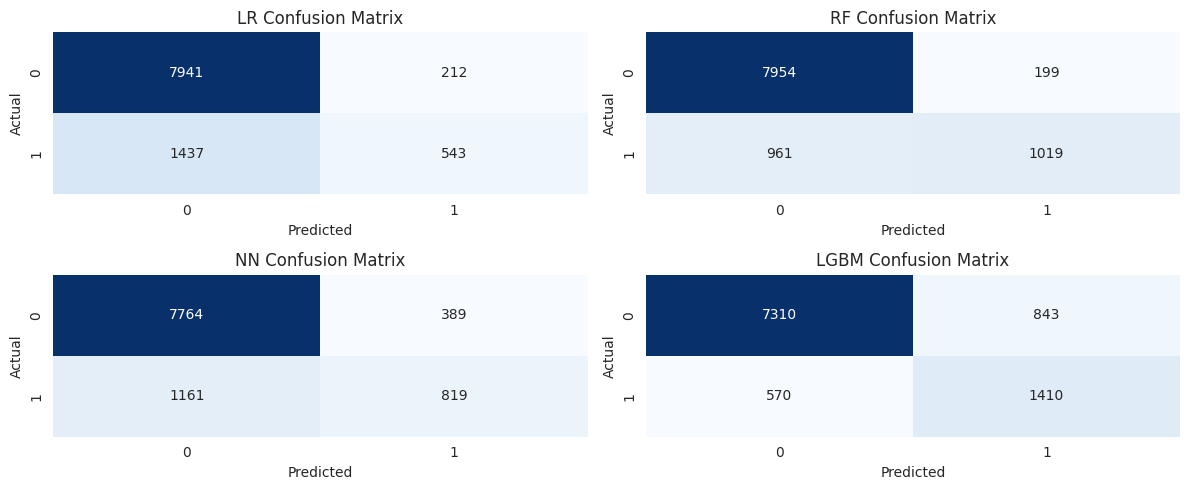

In [58]:
sns.set_style("darkgrid")

plt.figure(figsize=(12, 5))

models = [("LR", y_pred_lr_best), ("RF", y_pred_rf_best), ("NN", y_pred_nn_best), ("LGBM", y_pred_lg_best)]

for idx, (name, y_pred) in enumerate(models, start=1):
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(2, 2, idx)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

**ROC Curves for Best Models**

<Figure size 600x500 with 0 Axes>

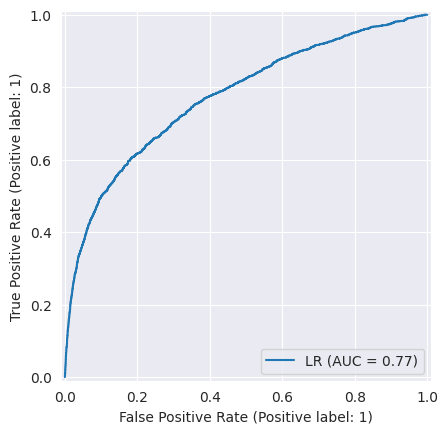

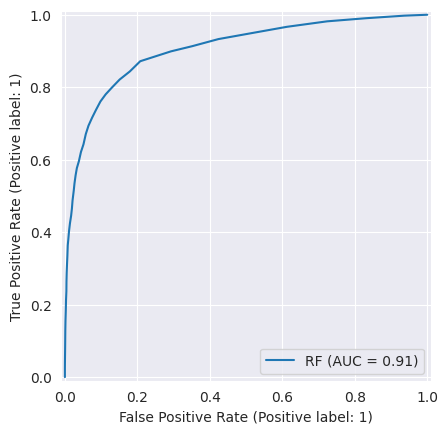

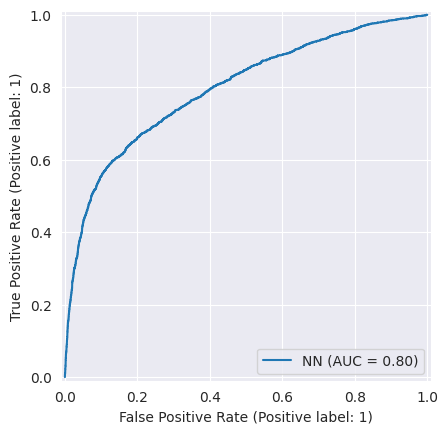

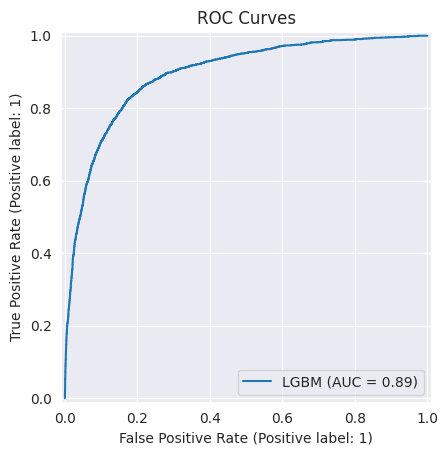

In [59]:
# ROC Curves
fig = plt.figure(figsize=(6, 5))

RocCurveDisplay.from_predictions(y_test, y_proba_lr_best, name="LR")
RocCurveDisplay.from_predictions(y_test, y_proba_rf_best, name="RF")
RocCurveDisplay.from_predictions(y_test, y_proba_nn_best, name="NN")
RocCurveDisplay.from_predictions(y_test, y_proba_lg_best, name="LGBM")
plt.title("ROC Curves")
plt.show()